# Final Project: Time and Daily Temperature Ranges

This Jupyter notebook analyzes the daily temperature ranges and their trends over time. Each year is sampled weekly, noting the average and standard deviation of temperature ranges for each country from 1950 to 2026.

### Step 1

The first code cell loads the CMIP6 dataset with OpenVisus into a `DBReader` object. An example read is made to test the user's environment.

In [2]:
import numpy as np
import OpenVisus as ov
from datetime import datetime
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pyspark import SparkContext
import math
import geopandas as gpd
from unidecode import unidecode
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import time
from datetime import datetime, timedelta
from utils import CountryFinder
import os
from matplotlib.cbook import boxplot_stats

class DBReader:
    def __init__(self):
        self.__db = ov.LoadDataset(
            "http://atlantis.sci.utah.edu/mod_visus?dataset=nex-gddp-cmip6"
        )
        self.__model     = "ACCESS-CM2"
        self.__scenario  = "historical"
        
        '''
        tasmax
        Daily Maximum Near-Surface Air Temperature
        Degrees Kelvin
        
        tasmin
        Daily Minimum Near-Surface Air Temperature
        Degrees Kelvin
        '''

    def __calculate_day_of_year(self, date_str):
        date = datetime.strptime(date_str, '%Y-%m-%d')
        start_of_year = datetime(date.year, 1, 1)
        day_of_year = (date - start_of_year).days   
        return day_of_year
        
    def __get_timestep(self, date_str):
        date = datetime.strptime(date_str, '%Y-%m-%d')
        day_of_year = self.__calculate_day_of_year(date_str)
        total_days = 365 + (1 if (date.year % 4 == 0 and date.year % 100 != 0) or (date.year % 400 == 0) else 0)
        return f"{date.year*total_days+day_of_year}"
        
    def read(self, timestamp, domax):
        timestep_index = int(self.__get_timestep(timestamp))
        return self.__db.read(
            time = timestep_index,
            quality = 0,
            field = f"{"tasmax" if domax else "tasmin"}_day_{self.__model}_{self.__scenario}_r1i1p1f1_gn"
        )

dbr = DBReader()
ex_min_temps = dbr.read('1953-01-01', False)
print(ex_min_temps.shape)

(600, 1440)


### Step 2

The second code cell uses the precomputed country matrix. Each longitude-latitude pair for an `np.ndarray` with shape `(600, 1440)` is assigned a country ID. This cell, although one line, confirms whether the user has the binary file.

In [5]:
country_matrix = np.fromfile("mapdata/cmat.bin").reshape((600, 1440)).astype(np.int32)

### Step 3

The third cell defines a function for displaying any `np.ndarray`'s with shape `(600, 1440)`. The previous two arrays are displayed here for further confirmation.

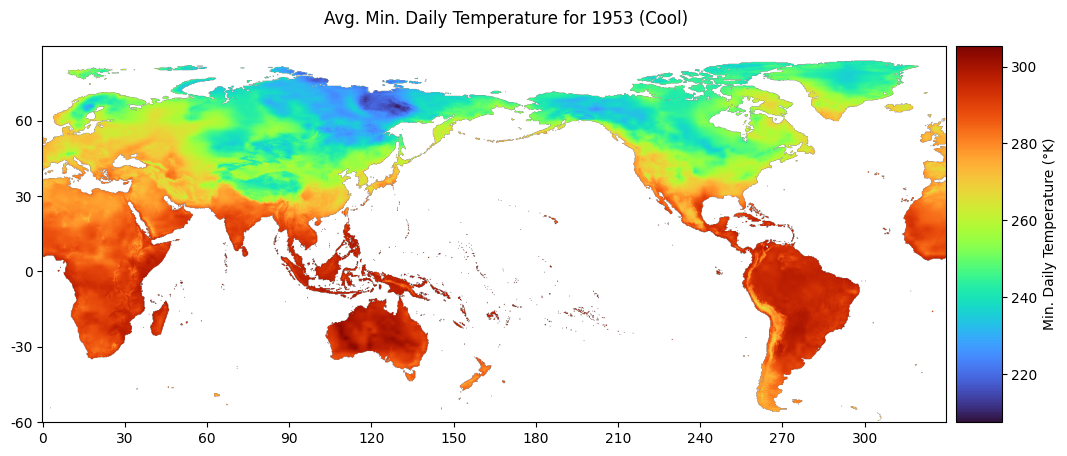

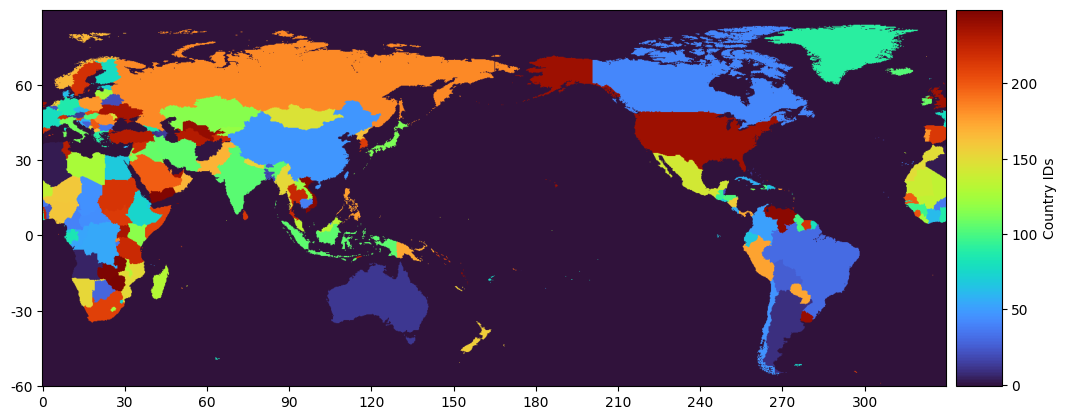

In [9]:
def show_map(data: np.ndarray, title: str):
    y_max, x_max = data.shape
    xlabels = [str(x) for x in range(0, 360, 30)]
    ylabels = [str(y) for y in range(-60, 91, 30)]
    xticks = np.linspace(0, x_max, len(xlabels))
    yticks = np.linspace(0, y_max, len(ylabels))
    
    # Create the plot
    fig, axes = plt.subplots(1, 1, figsize=(10, 8), constrained_layout=True)
    axes.set_xticks(xticks)
    axes.set_xticklabels(xlabels)
    axes.set_yticks(yticks)
    axes.set_yticklabels(ylabels)
    
    # Plot the data
    im = axes.imshow(data[:, :], origin='lower', cmap='turbo')
    
    divider = make_axes_locatable(axes)
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and pad as needed
    
    # Add the colorbar
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label(title)
    
    # Show the plot
    if title == 'Min. Daily Temperature (°K)':
        fig.suptitle("Avg. Min. Daily Temperature for 1953 (Cool)", ha='center', y=0.78)
        plt.savefig("mapdata/deleteme", dpi=150, bbox_inches = "tight")
    plt.show()

show_map(ex_min_temps, 'Min. Daily Temperature (°K)')
show_map(country_matrix, 'Country IDs')

### Step 3.5

Define array of tuples to analyze.

In [54]:
def country_tuples(country: str, country_matrix: np.array):
    cf = CountryFinder()
    cid = cf.cid(country)
    output = [[], []]
    for i in range(country_matrix.shape[0]):
        for j in range(country_matrix.shape[1]):
            if country_matrix[i][j] == cid:
                output[0].append(i)
                output[1].append(j)
    return np.array(output)

italy_tuples = country_tuples("Italy", country_matrix)
print(italy_tuples.shape)

(2, 529)


### Step 4

The following cell defines a function for computing the statistics from each country.

In [61]:
def day_stats(timestamp: str, country: str, country_matrix: np.array):
    idx_tuples = country_tuples(country, country_matrix)
    return np.array((
        np.mean(dbr.read(timestamp, False)[idx_tuples[0], idx_tuples[1]]),
        np.mean(dbr.read(timestamp, True)[idx_tuples[0], idx_tuples[1]])
    ))

ex_temp_tuple = day_stats("1950-01-01", "Italy", country_matrix)
print(ex_temp_tuple.shape)

(2,)


### Step 6

Write function to compute the temperature statistics for the first N days of the year.

In [82]:
def month_cstats(year: int, country: str, n = 20):
    output = np.zeros((2, n))
    timestamps = [(datetime(year=year, month=1, day=1) + timedelta(days=x)).strftime('%Y-%m-%d') for x in range(n)]
    for i in range(len(timestamps)):
        output[:,i] = day_stats(timestamps[i], country, country_matrix)
    return (
        boxplot_stats(output[0])[0],
        boxplot_stats(output[1])[0],
        boxplot_stats(output[1] - output[0])[0]
    )

start = time.perf_counter()
m1_cstats = month_cstats(1952, "Italy", 5)
print(m1_cstats[0])
end = time.perf_counter()
elapsed = end - start
print(f"Time to compute yearly temperature stats: {elapsed:.6f} seconds")

{'mean': np.float64(282.4475036621094), 'iqr': np.float64(0.2181396484375), 'cilo': np.float64(282.4550844737062), 'cihi': np.float64(282.7614072255125), 'whishi': np.float64(283.0059814453125), 'whislo': np.float64(282.48370361328125), 'fliers': array([281.43774414]), 'q1': np.float64(282.48370361328125), 'med': np.float64(282.6082458496094), 'q3': np.float64(282.70184326171875)}
Time to compute yearly temperature stats: 8.102402 seconds


### Step 7

With all the helper functions out of the way, now it is time to compute the yearly mean and stddev of temperature ranges for each country.

In [73]:
def months_cstats(years: tuple[int, int], country: str, n = 20):
    # index by year, country, mean/stddev
    output = []
    year_list = range(years[0], years[1]+1)
    for yr in year_list:
        print(f"Processing {yr}...", end='\r')
        output.append(month_cstats(yr, country, n))
    return output

year_tuple = (1950, 2010)
start = time.perf_counter()
italy_data = months_cstats(year_tuple, "Italy", 20)
end = time.perf_counter()
elapsed = end - start
print(f"Time to compute multi-year temperature stats: {elapsed:.6f} seconds")

Time to compute multi-year temperature stats: 2019.018337 seconds


### Step 8

Now that the final country statistics have been computed, data visualization can begin.

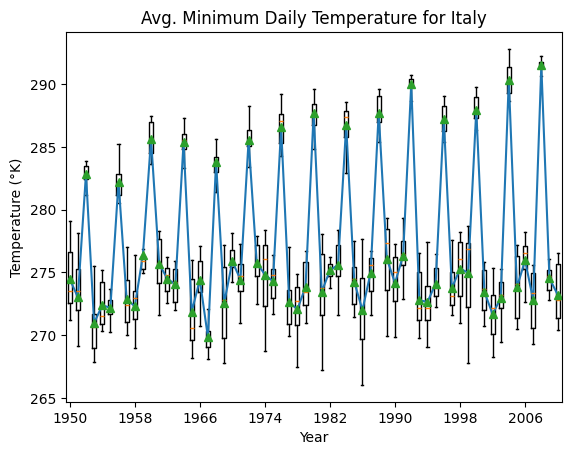

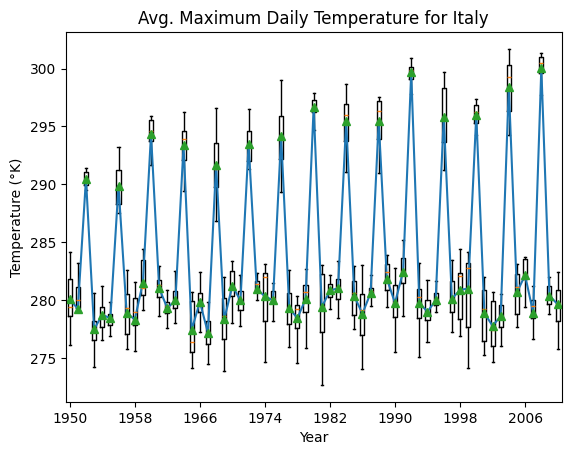

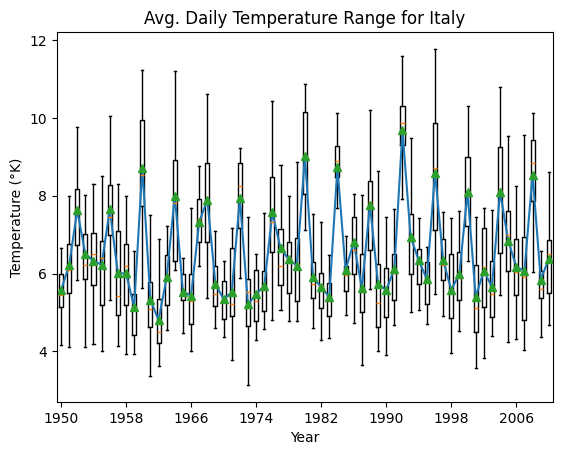

In [96]:
def graph_boxes(
    boxdata: list[dict], years: tuple[int, int],
    title: str, xlbl: str, ylbl: str,
    file_name: str
):
    year_list = np.arange(years[0], years[1]+1)
    means = [ x["mean"] for x in boxdata ]

    fig, ax = plt.subplots()
    ax.set_ylabel(ylbl)
    ax.set_xlabel(xlbl)
    ax.set_title(title)
    ax.bxp(boxdata, showmeans=True, showfliers=False)
    xticks, xlabels = plt.xticks()
    plt.plot(range(1, len(means)+1), means)
    plt.xticks(xticks[::8], year_list[::8])
    plt.savefig(f"mapdata/{file_name}")
    plt.show()
    plt.close()

graph_boxes(
    [x[0] for x in italy_data], year_tuple,
    "Avg. Minimum Daily Temperature for Italy",
    "Year",
    "Temperature (°K)",
    "italy_min"
)

graph_boxes(
    [x[1] for x in italy_data], year_tuple,
    "Avg. Maximum Daily Temperature for Italy",
    "Year",
    "Temperature (°K)",
    "italy_max"
)

graph_boxes(
    [x[2] for x in italy_data], year_tuple,
    "Avg. Daily Temperature Range for Italy",
    "Year",
    "Temperature (°K)",
    "italy_diff"
)

In [97]:
year_tuple = (1950, 2010)
start = time.perf_counter()
angola_data = months_cstats(year_tuple, "Angola", 20)
end = time.perf_counter()
elapsed = end - start
print(f"Time to compute multi-year temperature stats: {elapsed:.6f} seconds")

Time to compute multi-year temperature stats: 1967.800482 seconds


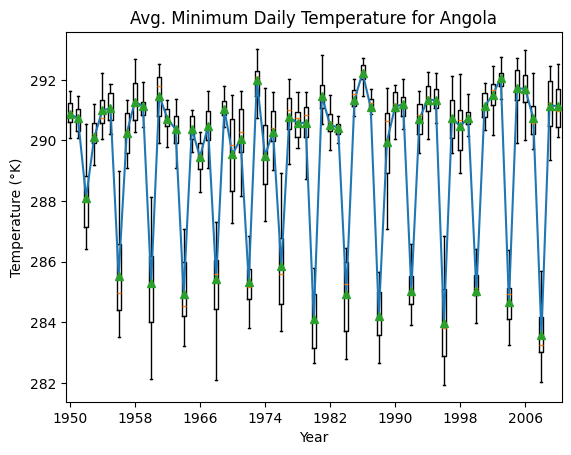

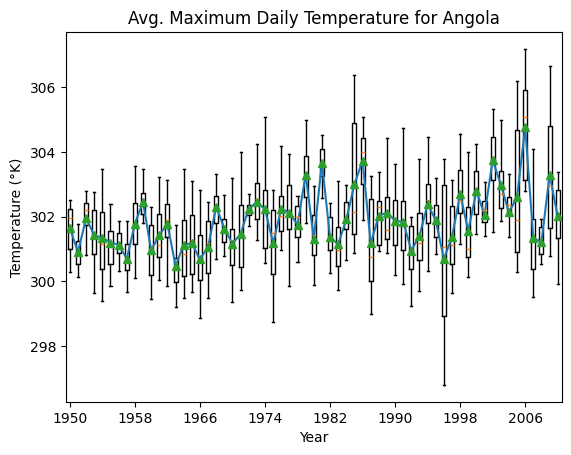

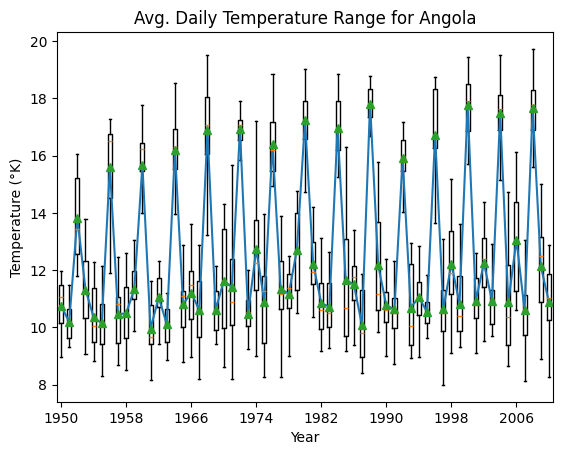

In [98]:
graph_boxes(
    [x[0] for x in angola_data], year_tuple,
    "Avg. Minimum Daily Temperature for Angola",
    "Year",
    "Temperature (°K)",
    "angola_min"
)

graph_boxes(
    [x[1] for x in angola_data], year_tuple,
    "Avg. Maximum Daily Temperature for Angola",
    "Year",
    "Temperature (°K)",
    "angola_max"
)

graph_boxes(
    [x[2] for x in angola_data], year_tuple,
    "Avg. Daily Temperature Range for Angola",
    "Year",
    "Temperature (°K)",
    "angola_diff"
)

In [99]:
year_tuple = (1950, 2010)
start = time.perf_counter()
kazakhstan_data = months_cstats(year_tuple, "Kazakhstan", 20)
end = time.perf_counter()
elapsed = end - start
print(f"Time to compute multi-year temperature stats: {elapsed:.6f} seconds")

Time to compute multi-year temperature stats: 1977.950671 seconds


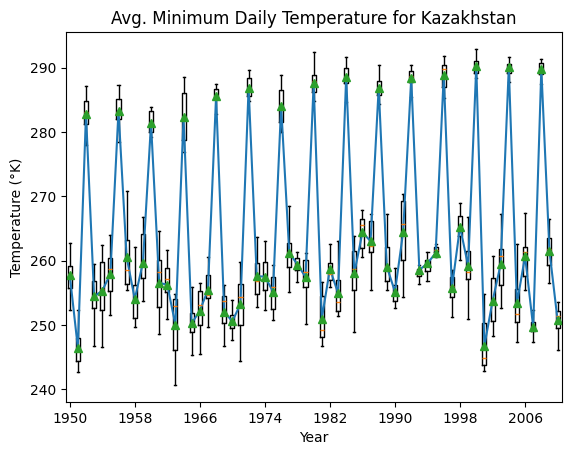

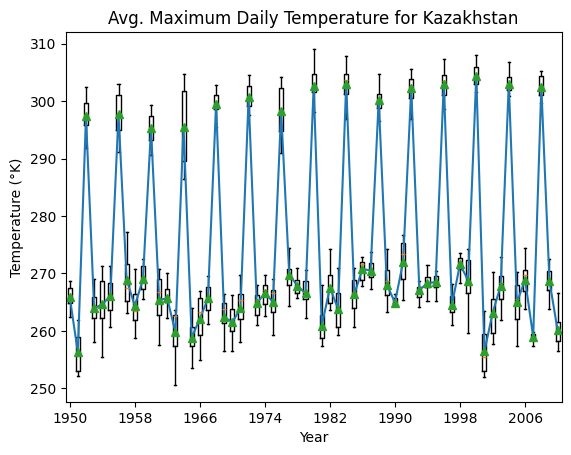

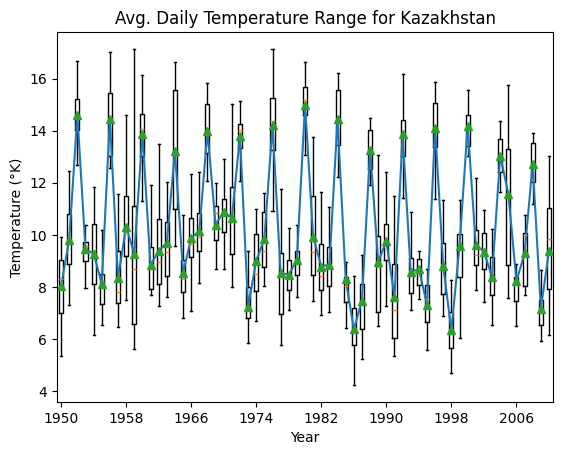

In [100]:
graph_boxes(
    [x[0] for x in kazakhstan_data], year_tuple,
    "Avg. Minimum Daily Temperature for Kazakhstan",
    "Year",
    "Temperature (°K)",
    "kazakhstan_min"
)

graph_boxes(
    [x[1] for x in kazakhstan_data], year_tuple,
    "Avg. Maximum Daily Temperature for Kazakhstan",
    "Year",
    "Temperature (°K)",
    "kazakhstan_max"
)

graph_boxes(
    [x[2] for x in kazakhstan_data], year_tuple,
    "Avg. Daily Temperature Range for Kazakhstan",
    "Year",
    "Temperature (°K)",
    "kazakhstan_diff"
)